<a href="https://colab.research.google.com/github/rehandg/Tute-Dude-Ds-Assignment-6/blob/main/Sales_Forecasting_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Sales Dataset.csv to Sales Dataset.csv
  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15         9.30          Low Fat         0.016047   
1           DRC01         5.92          Regular         0.019278   
2           FDN15        17.50          Low Fat         0.016760   
3           FDX07        19.20          Regular         0.000000   
4           NCD19         8.93          Low Fat         0.000000   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  182.0950            OUT010   
4              Household   53.8614            OUT013   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2009      Medium               Tier 3   
2            

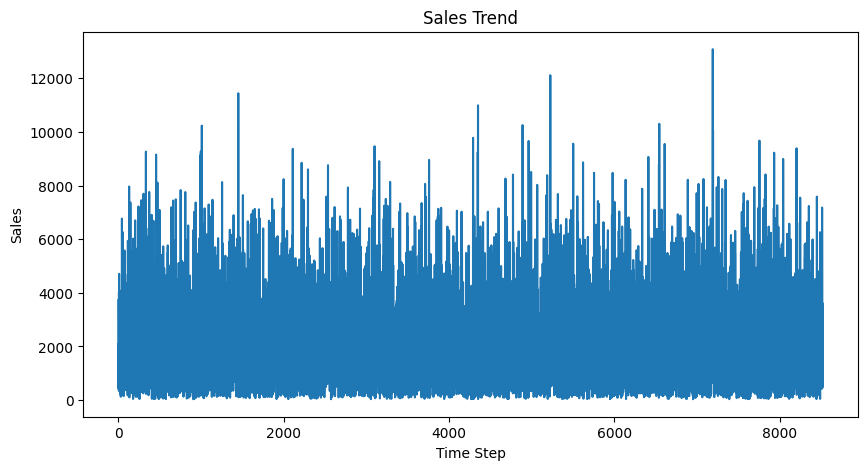

ADF Statistic: -91.76808169582388
p-value: 0.0
                               SARIMAX Results                                
Dep. Variable:      Item_Outlet_Sales   No. Observations:                 6816
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -60367.731
Date:                Sat, 09 May 2026   AIC                         120741.462
Time:                        15:52:17   BIC                         120761.943
Sample:                             0   HQIC                        120748.529
                               - 6816                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0031      0.012      0.250      0.803      -0.021       0.027
ma.L1         -1.0000      0.008   -131.130      0.000      -1.015      -0.985
sigma

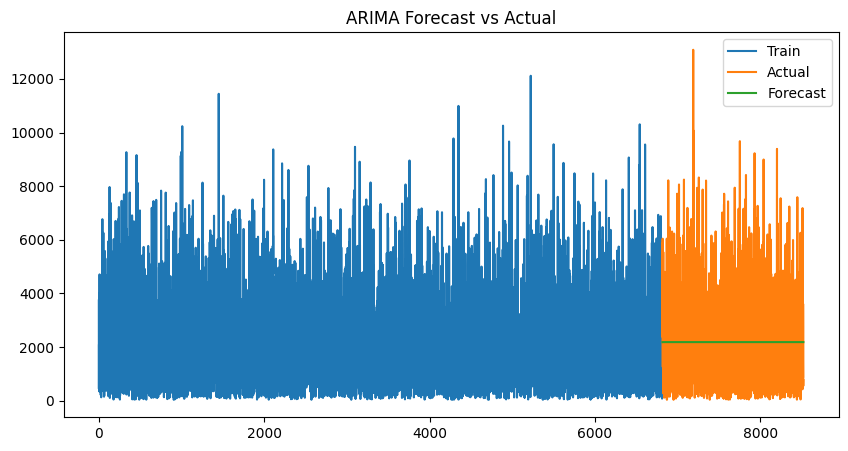

Future Sales Prediction:
6817    2182.275302
6818    2184.390254
6819    2184.396734
6820    2184.396754
6821    2184.396754
6822    2184.396754
6823    2184.396754
6824    2184.396754
6825    2184.396754
6826    2184.396754
Name: predicted_mean, dtype: float64


In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset
df = pd.read_csv("Sales Dataset.csv")

# Display First 5 Rows
print(df.head())

# Select Sales Column
sales_data = df['Item_Outlet_Sales'].astype(float)

# Create Sequential Index
sales_data.index = pd.RangeIndex(
    start=1,
    stop=len(sales_data) + 1,
    step=1
)

# Plot Sales Data
plt.figure(figsize=(10, 5))

plt.plot(sales_data)

plt.title("Sales Trend")
plt.xlabel("Time Step")
plt.ylabel("Sales")

plt.show()

# Stationarity Test
result = adfuller(sales_data)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Train Test Split
train_size = int(len(sales_data) * 0.8)

train = sales_data[:train_size]
test = sales_data[train_size:]

# ARIMA Model
model = ARIMA(train, order=(1, 1, 1))

# Train Model
model_fit = model.fit()

# Model Summary
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=len(test))

forecast.index = test.index

# Evaluation Metrics
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

# Forecast Visualization
plt.figure(figsize=(10, 5))

plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast')

plt.legend()

plt.title("ARIMA Forecast vs Actual")

plt.show()

# Future Forecast
future_steps = 10

future_forecast = model_fit.forecast(steps=future_steps)

print("Future Sales Prediction:")
print(future_forecast)